In [1]:
#Regina Martinez, Lauren Nunez, Saam Grami
#import libraries 

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

2026-03-22 20:57:20.352744: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-22 20:57:20.354697: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 20:57:20.553628: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-22 20:57:23.655979: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
#Data preparation
#Separate each point based on color
red_class = np.array([[1,5],[2,4],[7,7],[4,6],[6,4]])
blue_class = np.array([[6,9],[4,2],[8,6],[5,5],[3,8]])
print("red class:", red_class)
print("blue class:", blue_class)

#Put both matrices into a single matrix
#Define variable type. 
blue_and_red = np.vstack([red_class, blue_class], dtype =np.float32)
print("Combined matrix:", blue_and_red)

#Need to normalize the values so that they are between 0 and 1
normalized_data = blue_and_red/10.0 
print("Normalized data: ", normalized_data)

#Need to use one-hot encoding. Language machines can understand:
#"A value of 1 indicates the presence of that category and 0 indicates its absence"
#Reference: https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/
#Need to specift type to be float32 to be able to use tensorflow
data_enconding = np.array([[1,0],[1,0],[1,0],[1,0],[1,0],[0,1],[0,1],[0,1],[0,1],[0,1]], dtype=np.float32)


red class: [[1 5]
 [2 4]
 [7 7]
 [4 6]
 [6 4]]
blue class: [[6 9]
 [4 2]
 [8 6]
 [5 5]
 [3 8]]
Combined matrix: [[1. 5.]
 [2. 4.]
 [7. 7.]
 [4. 6.]
 [6. 4.]
 [6. 9.]
 [4. 2.]
 [8. 6.]
 [5. 5.]
 [3. 8.]]
Normalized data:  [[0.1 0.5]
 [0.2 0.4]
 [0.7 0.7]
 [0.4 0.6]
 [0.6 0.4]
 [0.6 0.9]
 [0.4 0.2]
 [0.8 0.6]
 [0.5 0.5]
 [0.3 0.8]]


In [3]:
#Neural network design using tensorflow
#Try different numbers of nodes per each layer?
#For the design. Need two inputs (x,y) and two outputs (blue or red)

#Forward pass:
#Reference: https://www.geeksforgeeks.org/deep-learning/back-propagation-with-tensorflow/
#Using reference: hidden layers use ReLU activation function and the output layer uses softmax
#2 inputs, 5 hidden layers, 2 outputs
hidden_layer_size = 100
model = tf.keras.Sequential([
    tf.keras.layers.Dense(hidden_layer_size, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])
model.summary()

/home/acrfa/miniconda3/envs/ros/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-22 20:57:25.877434: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,902 (159.77 KB)

 Trainable params: 40,902 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
#Loss function and optimizer
#Reference: https://www.geeksforgeeks.org/deep-learning/back-propagation-with-tensorflow/

#Using sparse categorical crossentropy (loss):
learning_rate = 0.15
epochs = 1300 

#Apparently there are two types of functions to plot loss 
#Reference: https://stackoverflow.com/questions/58565394/what-is-the-difference-between-sparse-categorical-crossentropy-and-categorical-c
loss_fn = tf.keras.losses.CategoricalCrossentropy()
print("Loss:", loss_fn)

#Using stochastic gradient descent (SGD): (Update model parameters)
optimizer = tf.keras.optimizers.SGD(learning_rate)
print("Optimizer:", optimizer)

model.summary()


Loss: <LossFunctionWrapper(<function categorical_crossentropy at 0x7da35b474a40>, kwargs={'from_logits': False, 'label_smoothing': 0.0, 'axis': -1})>
Optimizer: <keras.src.optimizers.sgd.SGD object at 0x7da3601622a0>


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,902 (159.77 KB)

 Trainable params: 40,902 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Backpropagation: 
#Reference: https://www.geeksforgeeks.org/deep-learning/back-propagation-with-tensorflow/

loss_history = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        logits = model(normalized_data) #inputs
        loss_value = loss_fn(data_enconding, logits) #outputs

    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss_value.numpy()}")

    loss_history.append(loss_value.numpy())

Epoch 100/1300, Loss: 0.6040987372398376
Epoch 200/1300, Loss: 0.40174490213394165
Epoch 300/1300, Loss: 0.3058606684207916
Epoch 400/1300, Loss: 0.34715431928634644
Epoch 500/1300, Loss: 0.26566705107688904
Epoch 600/1300, Loss: 0.09627577662467957
Epoch 700/1300, Loss: 0.019578974694013596
Epoch 800/1300, Loss: 0.004097586032003164
Epoch 900/1300, Loss: 0.0019133056048303843
Epoch 1000/1300, Loss: 0.0011456218780949712
Epoch 1100/1300, Loss: 0.0007982539245858788
Epoch 1200/1300, Loss: 0.0006030399235896766
Epoch 1300/1300, Loss: 0.0004763180040754378


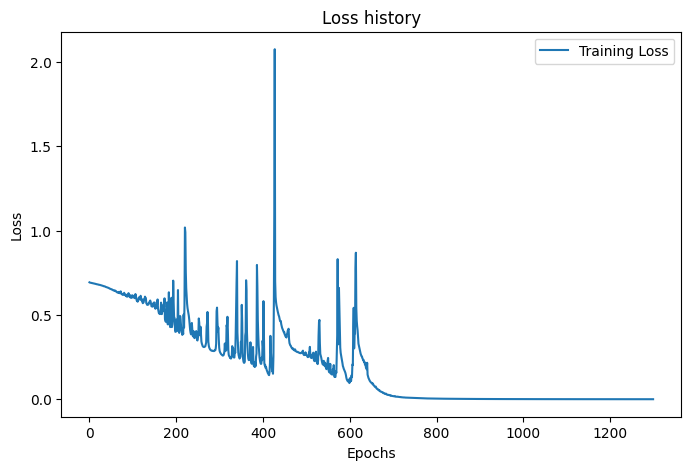

In [6]:
#Graph training loss data:
#Reference: https://www.geeksforgeeks.org/deep-learning/training-and-validation-loss-in-deep-learning/
plt.figure(figsize=(8,5))
plt.plot(loss_history, label='Training Loss')
plt.title('Loss history')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [7]:
#Mesh displaying the decision boundary so graph showing the "groups" from 0 to 10

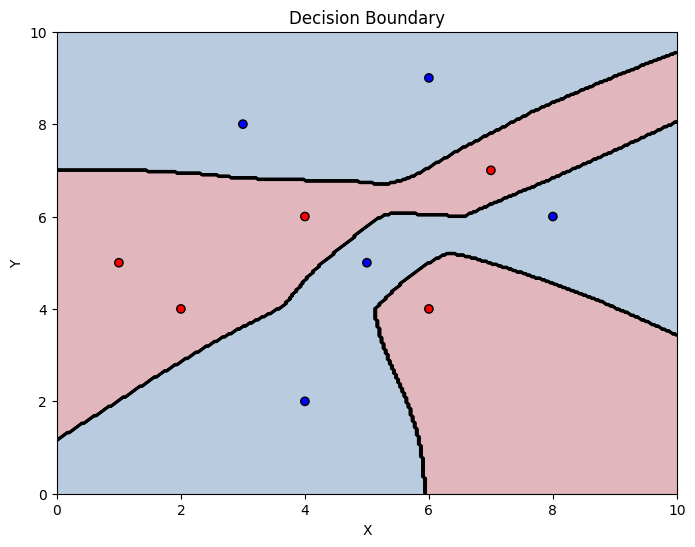

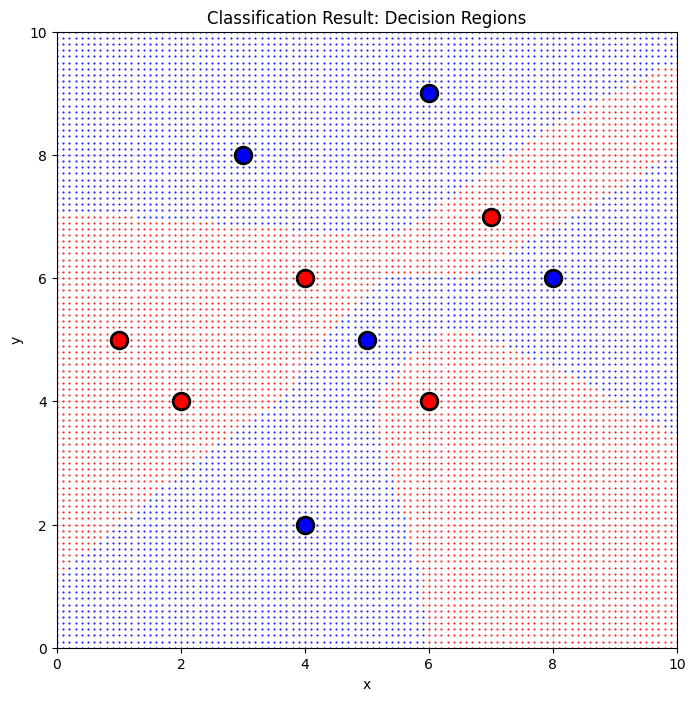

In [8]:
#Reference for plotting: https://www.geeksforgeeks.org/machine-learning/visualizing-classifier-decision-boundaries/
#Graph 1
x_range = np.linspace(0, 1, 300)
y_range = np.linspace(0, 1, 300)
xx, yy = np.meshgrid(x_range, y_range)

Z = np.argmax(model(np.c_[xx.ravel(), yy.ravel()]), axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx * 10, yy * 10, Z, alpha=0.3, cmap=plt.cm.RdBu)
plt.contour(xx * 10, yy * 10, Z, colors='black', linewidths=1.5)
plt.scatter(blue_and_red[:, 0], blue_and_red[:, 1],
            c=['red']*5 + ['blue']*5,
            edgecolor='k')

plt.title("Decision Boundary")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
plt.figure(figsize=(8, 8))
#Graph 2

test_points = []
for x_test in np.arange(0, 10.1, 0.1):
    for y_test in np.arange(0, 10.1, 0.1):
        test_points.append([x_test / 10.0, y_test / 10.0])

test_points = np.array(test_points)


preds = model.predict(test_points, verbose=0)

idx = 0
for x_test in np.arange(0, 10.1, 0.1):
    for y_test in np.arange(0, 10.1, 0.1):
        if preds[idx, 0] >= preds[idx, 1]:
            plt.plot(x_test, y_test, 'r.', markersize=1)
        else:
            plt.plot(x_test, y_test, 'b.', markersize=1)
        idx += 1 

for i in range(len(blue_and_red)):
    x_pt = blue_and_red[i, 0]
    y_pt = blue_and_red[i, 1]
    if i < 5:
        plt.plot(x_pt, y_pt, 'ro', markersize=12, markeredgecolor='black', markeredgewidth=2)
    else:
        plt.plot(x_pt, y_pt, 'bo', markersize=12, markeredgecolor='black', markeredgewidth=2)

plt.xlabel('x'); plt.ylabel('y'); plt.title('Classification Result: Decision Regions')
plt.xlim(0, 10); plt.ylim(0, 10); plt.grid(True, alpha=0.3); plt.show()